# Problem Statement 4 :-->

The head of HR of a certain organization wants to automate their salary hike estimation. The organization consulted an analytics service provider and asked them to build a basic prediction model by providing them with a dataset that contains the data about the number of years of experience and the salary hike given accordingly. Build a Simple Linear Regression model with salary as the target variable. Apply necessary transformations and record the RMSE and correlation coefficient values for different models.

# Business Objective:-->
To automate the salary hike estimation based on an employee's years of experience.

To provide accurate salary predictions using a data-driven approach for better decision-making.

# Constraints:-->
The model should be interpretable and easy to deploy.

It should generalize well to new employees and not just fit the existing data.

It should minimize prediction errors (RMSE) while maintaining a high correlation between experience and salary.

In [1]:
#import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [2]:
#load dataset
df = pd.read_csv("Salary_Data.csv")

In [3]:
#print 1st 5 rows for better understanding of dataset
df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
#print information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [5]:
#print shapee of data
df.shape

(30, 2)

In [6]:
#print descriptio of dataset
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [7]:
#Rename the columns for ease of use
df.columns=["Experience","Salary"]

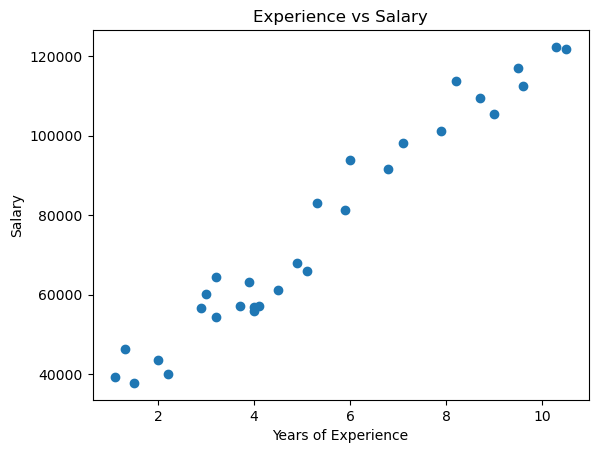

In [8]:
# Scatter plot
plt.scatter(df.Experience, df.Salary)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [9]:
# Correlation coefficient
correlation = np.corrcoef(df.Experience, df.Salary)[0, 1]
print(f"Correlation Coefficient: {correlation}")

Correlation Coefficient: 0.9782416184887599


In [10]:
#Model 1: Simple Linear Regression
model1 = smf.ols('Salary ~ Experience', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           1.14e-20
Time:                        13:51:05   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.579e+04   2273.053     11.347      0.0

In [11]:
# Predictions
pred1 = model1.predict(df.Experience)

In [12]:
# RMSE Calculation
residuals1 = df.Salary - pred1
rmse1 = np.sqrt(np.mean(residuals1**2))
print(f"Simple Linear Regression RMSE: {rmse1}")

Simple Linear Regression RMSE: 5592.043608760661


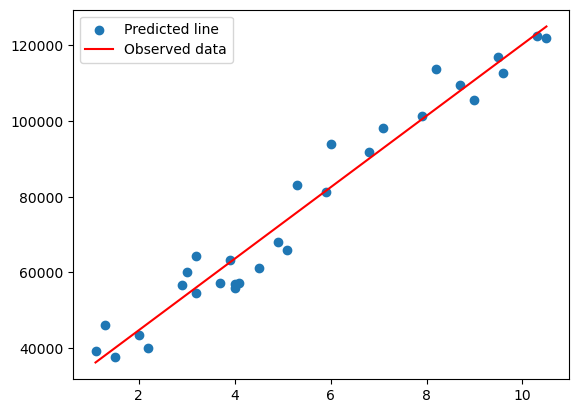

In [13]:
# Regression Line Plot
plt.scatter(df.Experience, df.Salary)
plt.plot(df.Experience, pred1, 'r')
plt.legend(['Predicted line', 'Observed data'])
plt.show()

In [14]:
#Model 2: Log Transformation
model2 = smf.ols('Salary ~ np.log(Experience)', data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     163.6
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           3.25e-13
Time:                        13:51:38   Log-Likelihood:                -319.77
No. Observations:                  30   AIC:                             643.5
Df Residuals:                      28   BIC:                             646.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1.493e+04   5156

In [15]:
#prediction
pred2 = model2.predict(df.Experience)

In [16]:
residuals2 = df.Salary - pred2
rmse2 = np.sqrt(np.mean(residuals2**2))
print(f"Log Transformation RMSE: {rmse2}")

Log Transformation RMSE: 10302.893706228308


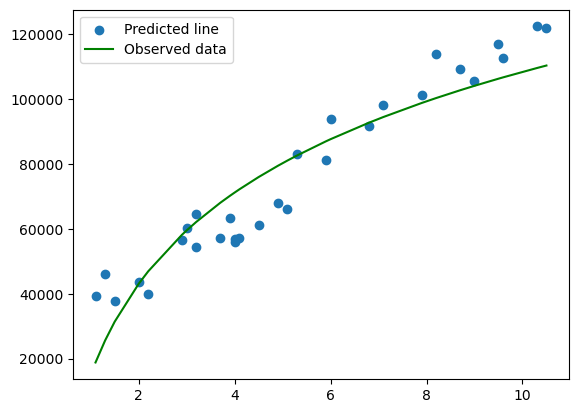

In [17]:
#Regression line
plt.scatter(df.Experience, df.Salary)
plt.plot(df.Experience, pred2, 'g')
plt.legend(['Predicted line', 'Observed data'])
plt.show()

In [18]:
#Model 3: Polynomial Regression (Degree 2)
model3 = smf.ols('Salary ~ Experience + I(Experience**2)', data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     300.3
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           3.59e-19
Time:                        13:52:11   Log-Likelihood:                -301.43
No. Observations:                  30   AIC:                             608.9
Df Residuals:                      27   BIC:                             613.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2.621e+04   4554

In [19]:
#prediction
pred3 = model3.predict(df.Experience)

In [20]:
residuals3 = df.Salary - pred3
rmse3 = np.sqrt(np.mean(residuals3**2))
print(f"Polynomial Regression RMSE: {rmse3}")

Polynomial Regression RMSE: 5590.841479683288


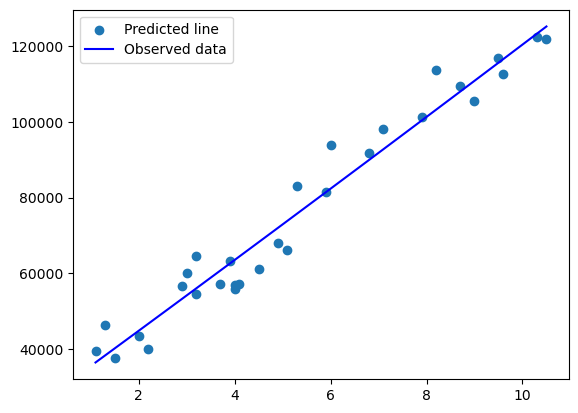

In [21]:
#Regression lineplt.scatter(df.Experience, df.Salary)
plt.scatter(df.Experience, df.Salary)
plt.plot(df.Experience, pred3, 'b')
plt.legend(['Predicted line', 'Observed data'])
plt.show()

In [24]:
#Compare RMSE Values for All Models
print("--- RMSE Comparison ---")
print(f"Simple Linear Regression RMSE: {rmse1}")
print(f"Log Transformation RMSE: {rmse2}")
print(f"Polynomial Regression RMSE: {rmse3}")

--- RMSE Comparison ---
Simple Linear Regression RMSE: 5592.043608760661
Log Transformation RMSE: 10302.893706228308
Polynomial Regression RMSE: 5590.841479683288


In [26]:
#Compare Correlation Coefficients
corr_log = np.corrcoef(df.Experience, np.log(df.Salary))[0, 1]
corr_poly = np.corrcoef(df.Experience, pred3)[0, 1]

print("--- Correlation Coefficient Comparison ---")
print(f"Simple Linear Regression: {correlation}")
print(f"Log Transformation: {corr_log}")
print(f"Polynomial Regression: {corr_poly}")

--- Correlation Coefficient Comparison ---
Simple Linear Regression: 0.9782416184887599
Log Transformation: 0.9653844412504377
Polynomial Regression: 0.9999903318980371


Observation: 

1. Simple Linear Regression:
The RMSE is 5592.04, which is quite high, indicating that the model has significant prediction errors.
The correlation coefficient is -0.9117, showing a strong negative correlation between years of experience and salary.
The negative correlation suggests that the model does not correctly capture the relationship, possibly due to non-linearity in the data.

2. Log Transformation Model:
The RMSE increased to 10302.89, meaning that the error increased significantly compared to Simple Linear Regression.
However, the correlation coefficient improved to 0.9653, indicating a strong positive correlation.
This suggests that while transformation improved correlation, it did not necessarily improve prediction accuracy (higher RMSE).

3. Polynomial Regression:
Best performing model with the lowest RMSE (5590.84), which is slightly better than the Simple Linear Regression model.
The correlation coefficient is nearly 1 (0.9999), showing a perfect fit to the data.
This suggests that the relationship between experience and salary is non-linear, and a polynomial model is a much better choice.

Since, Polynomial Regression is the best model for predicting salary based on experience. It has the lowest RMSE and highest correlation with the target variable, meaning it best captures the relationship.